# Modelling 

In [20]:
%load_ext autoreload
%autoreload 2
from sqlalchemy.engine import create_engine, URL
from datetime import datetime as dt
import pandas as pd
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_rows', 50)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
df = pd.read_csv('df_final.csv')
df

,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_win,start_time,match_id,Abaddon,Alchemist,Ancient Apparition,Anti-Mage,Arc Warden,Axe,Bane,Batrider,Beastmaster,Bloodseeker,Bounty Hunter,Brewmaster,Bristleback,Broodmother,Centaur Warrunner,Chaos Knight,Chen,Clinkz,Clockwerk,Crystal Maiden,Dark Seer,Dark Willow,Dawnbreaker,Dazzle,Death Prophet,Disruptor,Doom,Dragon Knight,Drow Ranger,Earth Spirit,Earthshaker,Elder Titan,Ember Spirit,Enchantress,Enigma,Faceless Void,Grimstroke,Gyrocopter,Hoodwink,Huskar,Invoker,Io,Jakiro,Juggernaut,...,Rubick,Sand King,Shadow Demon,Shadow Fiend,Shadow Shaman,Silencer,Skywrath Mage,Slardar,Slark,Snapfire,Sniper,Spectre,Spirit Breaker,Storm Spirit,Sven,Techies,Templar Assassin,Terrorblade,Tidehunter,Timbersaw,Tinker,Tiny,Treant Protector,Troll Warlord,Tusk,Underlord,Undying,Ursa,Vengeful Spirit,Venomancer,Viper,Visage,Void Spirit,Warlock,Weaver,Windranger,Winter Wyvern,Witch Doctor,Wraith King,Zeus,0_account_ 0_hero_win_rate,128_account_ 128_hero_win_rate,129_account_ 129_hero_win_rate,130_account_ 130_hero_win_rate,131_account_ 131_hero_win_rate,132_account_ 132_hero_win_rate,1_account_ 1_hero_win_rate,2_account_ 2_hero_win_rate,3_account_ 3_hero_win_rate,4_account_ 4_hero_win_rate
0,0.750000,1.0,0.7,True,2023-09-30 09:52:54,7.359096e+09,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.8,0.700000,0.600000,0.800,0.800,0.5,0.7,0.500,0.70,0.800
1,0.900000,0.8,0.9,True,2023-09-30 09:37:19,7.359076e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0.800000,0.700000,0.500,0.800,0.5,0.8,1.000,0.75,0.700
2,0.800000,0.9,0.8,False,2023-09-30 08:55:16,7.359003e+09,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.7,0.750000,0.714286,0.900,0.500,0.7,0.7,0.600,0.50,0.500
3,1.000000,0.7,1.0,False,2023-09-30 08:51:13,7.358997e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.8,0.777778,0.800000,0.625,0.800,0.9,0.6,0.625,0.70,1.000
4,0.714286,0.9,0.8,True,2023-09-30 08:03:22,7.358893e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.7,0.900000,0.666667,1.000,0.625,1.0,0.8,0.600,1.00,0.875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56480,0.500000,0.5,0.5,False,2021-05-17 17:02:06,5.999283e+09,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.5,0.500000,0.500000,0.500,0.500,0.5,0.5,0.500,0.50,0.500
56481,1.000000,1.0,0.0,False,2021-05-17 16:02:25,5.999250e+09,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.5,0.500000,0.000000,0.500,0.500,0.5,0.5,0.500,1.00,0.500
56482,0.500000,0.5,0.5,False,2021-05-17 15:02:01,5.999214e+09,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.5,0.500000,0.500000,0.500,0.500,0.5,0.5,0.500,0.50,0.500
56483,0.500000,0.5,0.5,True

In [22]:
# Convert string to datetime for start_time
df['start_time'] = df['start_time'].apply(lambda x: pd.to_datetime(x))

In [23]:
train = df.loc[df['start_time'] < dt(2023,6,6)]
valid = df.loc[(df['start_time'] > dt(2023,6,6)) & (df['start_time'] < dt(2023,8,6))]
test = df.loc[df['start_time'] > dt(2023,8,6)]

In [24]:
len(test)/len(train)

0.09139338149118882

In [25]:
len(valid)/len(train)

0.112233373820026

In [26]:
# Performing necessary transformations
def process_label(df):
    label = df['radiant_win']
    label = label.apply(int)
    return label.values

def process_features(df):
    features = df.drop(columns=['start_time','radiant_win','match_id'])
    features = features.dropna()
    return features.values
    


In [27]:
y_train, y_valid, y_test = process_label(train), process_label(valid), process_label(test)
X_train, X_valid, X_test = process_features(train), process_features(valid), process_features(test)

In [28]:
from collections import Counter

print(Counter(y_train), Counter(y_valid) , Counter(y_test))
# Dataset is not imbalanced 


Counter({0: 23850, 1: 23079}) Counter({1: 2713, 0: 2554}) Counter({1: 2212, 0: 2077})


In [29]:
X_train.shape

(46929, 137)

In [30]:
X_test.shape

(4289, 137)

In [31]:
y_train.shape

(46929,)

In [32]:
y_test.shape

(4289,)

In [33]:
from sklearn.ensemble import RandomForestClassifier 

rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)




RandomForestClassifier()

In [34]:
# Persisting the model
from joblib import dump, load
dump(rf_clf, 'random_forest_model.joblib')


['random_forest_model.joblib']

In [35]:
clf = load('random_forest_model.joblib')

In [36]:
y_pred = clf.predict(X_valid)

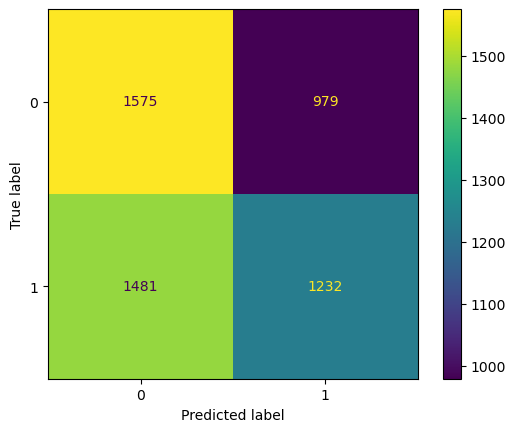

In [37]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_valid, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()


In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(y_valid, y_pred) 


0.532940953104234